In [1]:
import jax 
#jax.config.update("jax_enable_x64", True)

import lss_utils
import PT_field

import jax.numpy as jnp
import numpy as np

import matplotlib.pyplot as plt

if jax.config.jax_enable_x64:
    print("Using 64-bit precision.")
    base_dtype = jnp.float64
else:
    print("Using 32-bit precision.")
    base_dtype = jnp.float32


Using 32-bit precision.


In [2]:
from scipy.interpolate import CubicSpline

boxsize = 2500
kf = 2 * jnp.pi / boxsize
vol = boxsize**3

ng = 512
ng_E = 512

redshift = 0.0
OM0 = 0.30964

growth = PT_field.growth_D_f(redshift, OM0)[0] / PT_field.growth_D_f(0, OM0)[0]
growth_f = PT_field.growth_D_f(redshift, OM0)[1]
print(growth, growth_f)
print(jnp.pi*ng/boxsize)

pk_lin = np.loadtxt('/home/akitsukz/field_level/mPk_planck2018_massless_nu.dat')  # @ z=0
pk_lin_interp = CubicSpline(pk_lin[:,0], pk_lin[:,1]* growth**2)

1.0 0.52202797
0.6433981754551896


In [3]:
ng_pad = int(1.5*ng)   ### to avoid aliasing; for the quad fields, 1.5 is recommended, for cubic fields, 2.0 is recommended
ng_L = ng  
ng_L = int(1.1*ng)
if ng_L % 2 !=0:
    ng_L += 1
print(ng_L)

window_order = 2
interlace = True

model = PT_field.LPT_Forward(boxsize=boxsize, ng=ng, ng_L=ng_L, ng_E=ng_E,ng_pad=ng_pad,
                             mas_cfg=(window_order, interlace), 
                             rsd=True, lya=False, lpt_order=1, bias_order=2,
                             #renormalize=False,
                             renormalize=True,
                             dtype=base_dtype,
                             )

seed = 1995

key = jax.random.PRNGKey(seed)
gauss_3d_r = jax.random.normal(key, shape=(ng, ng, ng), dtype=base_dtype)
gauss_3d_r -= jnp.mean(gauss_3d_r)

gauss_3d = jnp.fft.rfftn(gauss_3d_r, norm='ortho') * jnp.sqrt(2.)
gauss_3d = gauss_3d.at[0,0,0].set(0.0)

delta_k = model.linear_modes(pk_lin, gauss_3d)

564


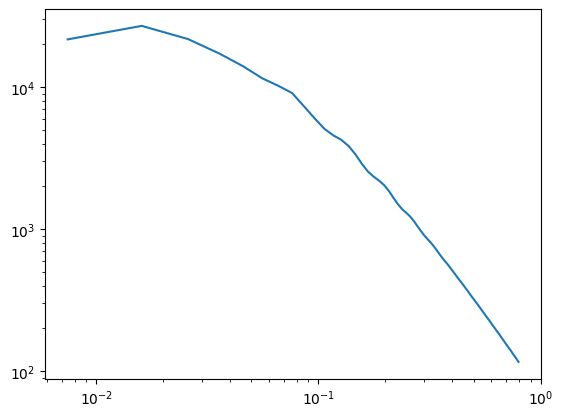

In [4]:
k_edges = jnp.linspace(0.0, 0.8, 80)
mu_edges = jnp.array([0.0, 1.0])

measure_pk = lss_utils.Measure_Pk(boxsize, ng, k_edges, dtype=base_dtype)

pk_ic = measure_pk(delta_k)

plt.plot(pk_ic[:,0], pk_ic[:,1], label='ICs')

plt.xscale('log')
plt.yscale('log')

#k_arr, pks_auto, Nmodes = PT_field.compute_pks_2d(shifted_fields, mu_edges, measure_pk=measure_pk_E)

#pks_auto: (n_fields, Nk, Nmu)

In [10]:
z_edges = jnp.linspace(0.0, 1., 50)
z_mid = 0.5 * (z_edges[1:] + z_edges[:-1])
print(z_edges)
chi_edges = PT_field.chi_of_z(z_edges, OM0)
print(chi_edges)
D_mid, f_mid = PT_field.growth_D_f(z_mid, OM0)

def test_b1(z):
    return 0.5 + 1.0 / PT_field.growth_D_f(z, OM0)[0]

def test_b2(b1):
    return 0.412 - 2.143 * b1 + 0.929 * b1 **2 + 0.008 *b1**3

def test_bG2(b1):
    return -2/.7 * (b1 - 1)

beta_mid = []
beta_mid.append(np.ones_like(z_mid, dtype=base_dtype))  # for 1
beta_mid.append(test_b1(z_mid)) # for delta
beta_mid.append(test_b2(beta_mid[1])) # for deltra^2
beta_mid.append(test_bG2(beta_mid[1])) # for G2
beta_mid.append(-3./7.*f_mid) # for G2_zz
beta_mid = jnp.array(beta_mid)  #(num_fields, Nbias)
#beta_mid = jnp.zeros((5, len(z_mid)), dtype=base_dtype)
#beta_mid = beta_mid.at[0].set(1.0)
print(beta_mid)
print(beta_mid.shape)

[0.         0.02040816 0.04081633 0.06122449 0.08163265 0.10204081
 0.12244898 0.14285713 0.1632653  0.18367347 0.20408162 0.2244898
 0.24489796 0.26530612 0.28571427 0.30612245 0.3265306  0.34693876
 0.36734694 0.3877551  0.40816325 0.42857143 0.4489796  0.46938774
 0.48979592 0.5102041  0.53061223 0.5510204  0.57142854 0.59183675
 0.6122449  0.63265306 0.6530612  0.67346936 0.6938775  0.7142857
 0.7346939  0.75510204 0.7755102  0.79591835 0.8163265  0.83673465
 0.85714287 0.877551   0.8979592  0.9183673  0.9387755  0.95918363
 0.97959185 1.        ]
[   0.        60.89094  121.19533  180.90688  240.02031  298.53128
  356.4358   413.7306   470.41354  526.48236  581.93616  636.77435
  690.9968   744.6043   797.59796  849.97955  901.75104  952.91516
 1003.47485 1053.4336  1102.795   1151.5632  1199.743   1247.3392
 1294.3564  1340.7999  1386.6759  1431.9896  1476.7468  1520.9537
 1564.6161  1607.7413  1650.3351  1692.4036  1733.9541  1774.9929
 1815.5273  1855.5635  1895.1078  1934.1681

In [11]:
shifted_fields_lc = model.get_shifted_fields_lightcone_fast(delta_k, D_ic=PT_field.growth_D_f(redshift, OM0)[0], 
                                                            chi_edges=chi_edges, D_mid=D_mid, beta_mid=beta_mid, 
                                                            growth_powers=jnp.array([0.0, 1.0, 2.0, 2.0, 2.0]),
                                                            f_mid=f_mid,
                                                            field_type='scalar')


In [12]:
final_field_k_lc = shifted_fields_lc.sum(axis=0)
final_field_r_lc = model.irfftn(final_field_k_lc)

In [13]:
def plot_lightcone_slice(field_r_lc,
                         axis='z',
                         index=None,
                         boxsize=None,
                         cmap='RdBu_r',
                         vmin=None,
                         vmax=None):
    """
    Plot a 2D slice of a 3D light-cone field using imshow.

    Parameters
    ----------
    field_r_lc : array_like
        3D real-space field, shape (nx, ny, nz).
        Can be a JAX array or a NumPy array.
    axis : {'x', 'y', 'z'}
        Direction along which to slice.
    index : int or None
        Index of the slice. If None, the central slice is used.
    boxsize : float or None
        Box size in the same units as the field coordinates.
        If provided, it is used to set the imshow extent.
    cmap : str
        Matplotlib colormap.
    vmin, vmax : float or None
        Color scale limits for imshow. If None, they are chosen automatically.
    """
    if isinstance(field_r_lc, jnp.ndarray):
        field = np.array(field_r_lc)
    else:
        field = field_r_lc

    nx, ny, nz = field.shape

    # Choose slice index
    if index is None:
        if axis == 'x':
            index = nx // 2
        elif axis == 'y':
            index = ny // 2
        else:
            index = nz // 2

    # Extract 2D slice
    if axis == 'x':
        slice2d = field[index, :, :]
        xlabel, ylabel = 'y', 'z'
        nx2, ny2 = ny, nz
    elif axis == 'y':
        slice2d = field[:, index, :]
        xlabel, ylabel = 'x', 'z'
        nx2, ny2 = nx, nz
    else:  # 'z'
        slice2d = field[:, :, index]
        xlabel, ylabel = 'x', 'y'
        nx2, ny2 = nx, ny

    # Set extent if boxsize is given
    if boxsize is not None:
        dx = boxsize / nx
        dy = boxsize / ny
        extent = (0.0, boxsize, 0.0, boxsize)
    else:
        extent = None

    plt.figure(figsize=(6, 5))
    im = plt.imshow(
        slice2d.T,      # transpose so that x→horizontal, y→vertical
        origin='lower',
        cmap=cmap,
        extent=extent,
        vmin=vmin,
        vmax=vmax,
        aspect='equal'
    )
    plt.colorbar(im, label='field value')
    plt.xlabel(xlabel if boxsize is None else f'{xlabel} [Mpc/h]')
    plt.ylabel(ylabel if boxsize is None else f'{ylabel} [Mpc/h]')
    plt.title(f'Light-cone slice along {axis}-axis (index = {index})')
    plt.tight_layout()
    plt.show()


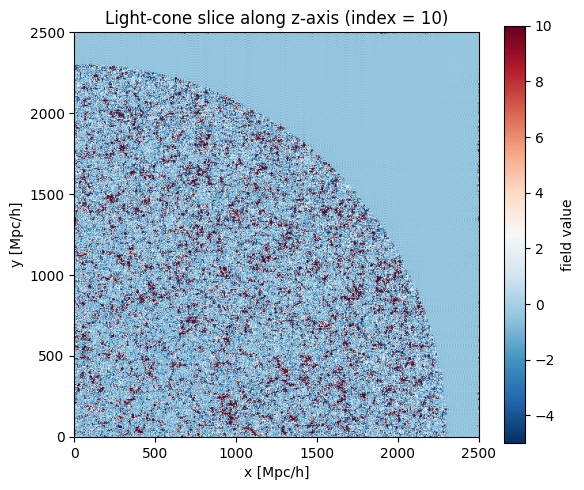

In [21]:
plot_lightcone_slice(
    final_field_r_lc,
    axis='z',         
    index=10,        # specify an int
    boxsize=model.boxsize,
    cmap='RdBu_r',
    vmin=-5, vmax=10
)
